<a href="https://colab.research.google.com/github/tjdux/Introduction-to-Machine-Learning-with-Python/blob/main/04_5_%EC%83%81%ED%98%B8%EC%9E%91%EC%9A%A9%EA%B3%BC_%EB%8B%A4%ED%95%AD%EC%8B%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 노트북이 코랩에서 실행 중인지 체크합니다.
import os
import sys
if 'google.colab' in sys.modules:
    if not os.path.isdir('mglearn'):
        # mglearn을 다운받고 압축을 풉니다.
        !wget -q -O mglearn.tar.gz https://bit.ly/mglearn-tar-gz
        !tar -xzf mglearn.tar.gz
    !wget -q -O data.tar.gz https://bit.ly/data-tar-gz
    !tar -xzf data.tar.gz
    # 나눔 폰트를 설치합니다.
    !sudo apt-get -qq -y install fonts-nanum
    import matplotlib.font_manager as fm
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
    for fpath in font_files:
        fm.fontManager.addfont(fpath)

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 121713 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [2]:
import sklearn
from preamble import *
import matplotlib

# 나눔 폰트를 사용합니다.
matplotlib.rc('font', family='NanumBarunGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

/content/mglearn/datasets.py:31: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


In [17]:
# wave 데이터 로드
X, y = mglearn.datasets.make_wave(n_samples=120)
print(X.shape)

(120, 1)


In [18]:
# 구간 분할
from sklearn.preprocessing import KBinsDiscretizer

kb = KBinsDiscretizer(n_bins=10, strategy="uniform",
                      encode="onehot-dense")
X_binned = kb.fit_transform(X)

- 구간 분할로 구간 별 상숫값을 학습한 선형 모델에 기울기를 추가하는 방법: 구간으로 분할된 데이터에 원래 특성 (여기서는 x축)을 다시 추가
- ➡️ 11차원 데이터셋이 만들어짐
- ➡️ x축 특성 한 개가 추가되었으므로 기울기도 하나

In [5]:
X_combined = np.hstack([X, X_binned])
print(X_combined.shape)

(120, 11)


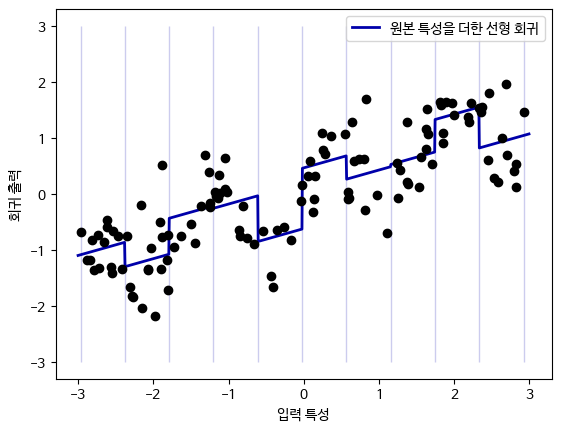

In [7]:
# 구간으로 분할된 특성과 하나의 기울기를 사용한 선형 회귀
from sklearn.linear_model import LinearRegression

reg = LinearRegression().fit(X_combined, y)

line = np.linspace(-3, 3, 1000, endpoint=False).reshape(-1, 1)
line_binned = kb.transform(line)

line_combined = np.hstack([line, line_binned])
plt.plot(line, reg.predict(line_combined), label="원본 특성을 더한 선형 회귀")

plt.vlines(kb.bin_edges_[0], -3, 3, linewidth=1, alpha=.2)
plt.legend(loc="best")
plt.ylabel("회귀 출력")
plt.xlabel("입력 특성")
plt.plot(X[:, 0], y, 'o', c='k')

## 01 상호작용
- 구간 별로 다른 기울기를 가지게 하기 위해서 상호작용 특성 추가
- 구간 특성과 원본 특성의 곱
- == 각 구간에 대한 x축 특성의 복사본
- == 구간 안에서는 원본 특성이고 다른 곳에서는 0

In [8]:
X_product = np.hstack([X_binned, X*X_binned])
print(X_product.shape)

(120, 20)


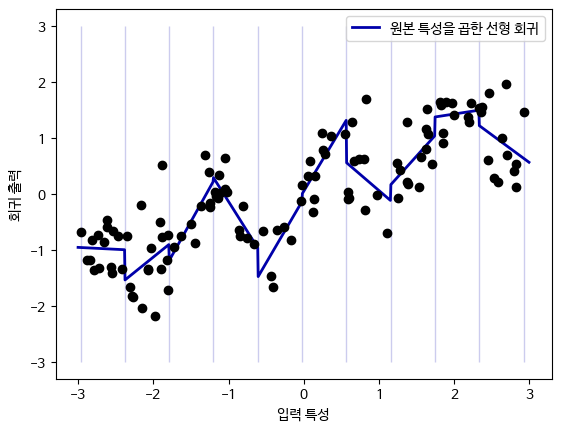

In [9]:
# 구간별 기울기가 다른 선형 회귀

reg = LinearRegression().fit(X_product, y)

line_product = np.hstack([line_binned, line*line_binned])
plt.plot(line, reg.predict(line_product), label="원본 특성을 곱한 선형 회귀")

plt.vlines(kb.bin_edges_[0], -3, 3, linewidth=1, alpha=.2)

plt.plot(X[:, 0], y, 'o', c='k')
plt.ylabel("회귀 출력")
plt.xlabel("입력 특성")
plt.legend(loc="best")
plt.show()

- ➡️ 각 구간에서 절편과 기울기가 모두 다름

## 02 다항식
- 연속형 특성을 확장하는 방법
  - 구간 나누기
  - 원본 특성의 다항식을 추가
- 특성 $x$가 주어지면 $x^2$, $x^3$,$x^4$ 등을 시도해볼 수 있음

In [14]:
from sklearn.preprocessing import PolynomialFeatures

# x**10까지 고차항을 추가
# include_bias=True: 절편에 해당하는 1인 특성을 추가
poly = PolynomialFeatures(degree=10, include_bias=False)
poly.fit(X)
X_poly = poly.transform(X)

# 10개의 특성 생성
print(f"X_poly.shape: {X_poly.shape}")

X_poly.shape: (120, 10)


In [15]:
# X와 X_poly의 값 비교
print(f"X 원소:\n{X[:5]}")
print(f"X_poly 원소:\n{X_poly[:5]}")

X 원소:
[[-0.753]
 [ 2.704]
 [ 1.392]
 [ 0.592]
 [-2.064]]
X_poly 원소:
[[   -0.753     0.567    -0.427     0.321    -0.242     0.182    -0.137
      0.103    -0.078     0.058]
 [    2.704     7.313    19.777    53.482   144.632   391.125  1057.714
   2860.36   7735.232 20918.278]
 [    1.392     1.938     2.697     3.754     5.226     7.274    10.125
     14.094    19.618    27.307]
 [    0.592     0.35      0.207     0.123     0.073     0.043     0.025
      0.015     0.009     0.005]
 [   -2.064     4.26     -8.791    18.144   -37.448    77.289  -159.516
    329.222  -679.478  1402.367]]


In [16]:
# get_feature_names_out(): 특성의 의미
print(f"항 이름:\n{poly.get_feature_names_out()}")

항 이름:
['x0' 'x0^2' 'x0^3' 'x0^4' 'x0^5' 'x0^6' 'x0^7' 'x0^8' 'x0^9' 'x0^10']


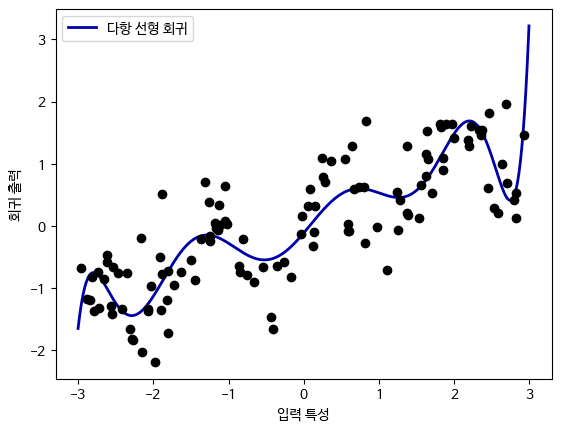

In [19]:
# 10차 다항식을 이용한 다항 선형 회귀

reg = LinearRegression().fit(X_poly, y)

line_poly = poly.transform(line)
plt.plot(line, reg.predict(line_poly), label="다항 선형 회귀")
plt.plot(X[:, 0], y, 'o', c='k')
plt.ylabel("회귀 출력")
plt.xlabel("입력 특성")
plt.legend(loc="best")
plt.show()

- 다항식 특성은 1차원 데이터셋에서도 매우 부드러운 곡선을 만들지만, 고차원 다항식은 데이터가 부족한 영역에서 너무 민감하게 작동함

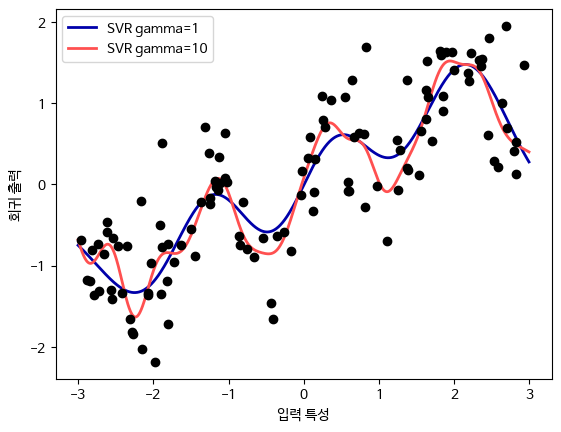

In [20]:
# 커널 SVM 모델과 비교
# RBF 커널 SVM의 gamma 매개변수 변화에 따른 비교
from sklearn.svm import SVR

for gamma in [1, 10]:
  svr = SVR(gamma=gamma).fit(X, y)
  plt.plot(line, svr.predict(line), label=f"SVR gamma={gamma}")

plt.plot(X[:, 0], y, 'o', c='k')
plt.ylabel('회귀 출력')
plt.xlabel("입력 특성")
plt.legend(loc="best")
plt.show()

- 더 복잡한 모델인 커널 SVM을 사용해 특성 데이터를 변환하지 않고 다항 회귀와 비슷한 복잡도를 가진 예측을 만들 수 있음

## 03 적용 (보스턴 주택 가격 데이터셋)

In [22]:
# 데이터 로드
from sklearn.model_selection import train_test_split

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]
X_train, X_test, y_train, y_test = train_test_split(data, target,
                                                    random_state=0)

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3911361854.py:5: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


In [24]:
# 스케일 조정
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
# 차수가 2인 다항식 특성 생성

# include_bias=True (기본값): 절편에 해당하는 1인 특성을 추가
poly = PolynomialFeatures(degree=2).fit(X_train_scaled)
X_train_poly = poly.transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)
print(f"X_train.shape: {X_train.shape}")
print(f"X_train_poly.shape: {X_train_poly.shape}")

X_train.shape: (379, 13)
X_train_poly.shape: (379, 105)


In [27]:
# 특성 이름
print(f"다항 특성 이름:\n{poly.get_feature_names_out()}")

다항 특성 이름:
['1' 'x0' 'x1' 'x2' 'x3' 'x4' 'x5' 'x6' 'x7' 'x8' 'x9' 'x10' 'x11' 'x12'
 'x0^2' 'x0 x1' 'x0 x2' 'x0 x3' 'x0 x4' 'x0 x5' 'x0 x6' 'x0 x7' 'x0 x8'
 'x0 x9' 'x0 x10' 'x0 x11' 'x0 x12' 'x1^2' 'x1 x2' 'x1 x3' 'x1 x4' 'x1 x5'
 'x1 x6' 'x1 x7' 'x1 x8' 'x1 x9' 'x1 x10' 'x1 x11' 'x1 x12' 'x2^2' 'x2 x3'
 'x2 x4' 'x2 x5' 'x2 x6' 'x2 x7' 'x2 x8' 'x2 x9' 'x2 x10' 'x2 x11'
 'x2 x12' 'x3^2' 'x3 x4' 'x3 x5' 'x3 x6' 'x3 x7' 'x3 x8' 'x3 x9' 'x3 x10'
 'x3 x11' 'x3 x12' 'x4^2' 'x4 x5' 'x4 x6' 'x4 x7' 'x4 x8' 'x4 x9' 'x4 x10'
 'x4 x11' 'x4 x12' 'x5^2' 'x5 x6' 'x5 x7' 'x5 x8' 'x5 x9' 'x5 x10'
 'x5 x11' 'x5 x12' 'x6^2' 'x6 x7' 'x6 x8' 'x6 x9' 'x6 x10' 'x6 x11'
 'x6 x12' 'x7^2' 'x7 x8' 'x7 x9' 'x7 x10' 'x7 x11' 'x7 x12' 'x8^2' 'x8 x9'
 'x8 x10' 'x8 x11' 'x8 x12' 'x9^2' 'x9 x10' 'x9 x11' 'x9 x12' 'x10^2'
 'x10 x11' 'x10 x12' 'x11^2' 'x11 x12' 'x12^2']


In [30]:
# Ridge를 사용해 상호작용 특성이 있는 데이터와 없는 데이터에 대해 성능 비교
from sklearn.linear_model import Ridge

ridge = Ridge().fit(X_train_scaled, y_train)
print(f"상호작용 특성이 없을 때 점수: {round(ridge.score(X_test_scaled, y_test), 3)}")
ridge = Ridge().fit(X_train_poly, y_train)
print(f"상호작용 특성이 있을 때 점수: {round(ridge.score(X_test_poly, y_test), 3)}")

상호작용 특성이 없을 때 점수: 0.621
상호작용 특성이 있을 때 점수: 0.753


In [32]:
# 랜덤 포레스트를 사용해 상호작용 특성이 있는 데이터와 없는 데이터에 대해 성능 비교
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=0).fit(X_train_scaled, y_train)
print(f"상호작용 특성이 없을 때 점수: {round(rf.score(X_test_scaled, y_test), 3)}")
rf = RandomForestRegressor(n_estimators=100, random_state=0).fit(X_train_poly, y_train)
print(f"상호작용 특성이 있을 때 점수: {round(rf.score(X_test_poly, y_test), 3)}")

상호작용 특성이 없을 때 점수: 0.795
상호작용 특성이 있을 때 점수: 0.78
